# SVM for classification

Load IRIS dataset, check its contents:


In [1]:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[0:5])
#print(iris.data)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


Split data into training and testing parts:

In [2]:
from sklearn.model_selection import train_test_split
X=iris.data
y=iris.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Use a Support Vector Machine for classification:


In [ ]:
from sklearn.svm import SVC
SVMmodel=SVC(kernel='linear')
SVMmodel.fit(X_train,y_train)
SVMmodel.get_params()
SVMmodel.score(X_test,y_test)

0.9333333333333333

Let's explore more now.

*   Choose only first two features (columns) of iris.data
*   SVM is in its basic form a 2-class classifier, so eliminate iris.target =2 from the data



In [3]:
import numpy as np

# garder uniquement les 2 premières features
X = iris.data[:, :2]
y = iris.target

# enlever la classe 2
mask = (y != 2)
X = X[mask]
y = y[mask]

print(X.shape, y.shape)
print("Classes restantes:", np.unique(y))


(100, 2) (100,)
Classes restantes: [0 1]


Plot scatterplots of targets 0 and 1 and check the separability of the classes:

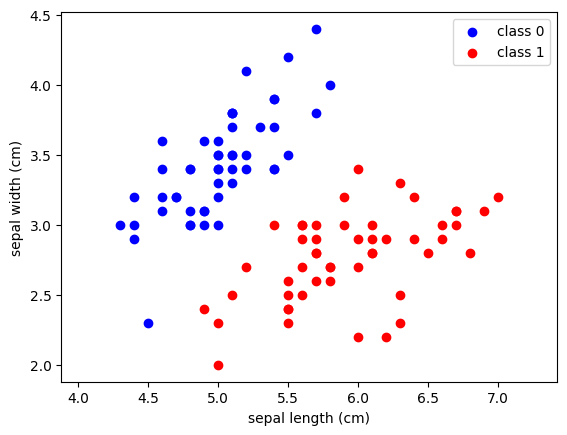

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='class 1')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.axis('equal')
plt.show()



Train and test the SVM classifier, play with regularization parameter C (either use the default value or try e.g. 200)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SVMmodel = SVC(kernel='linear', C=200)
SVMmodel.fit(X_train, y_train)

print("Score test:", SVMmodel.score(X_test, y_test))


Score test: 1.0


Show support vectors in the 2D plot, plot the decision line from equation [w0 w1]*[x0 x1] + b = 0:

W = [[ 6.3154899  -5.26238666]]
b = [-17.31642492]


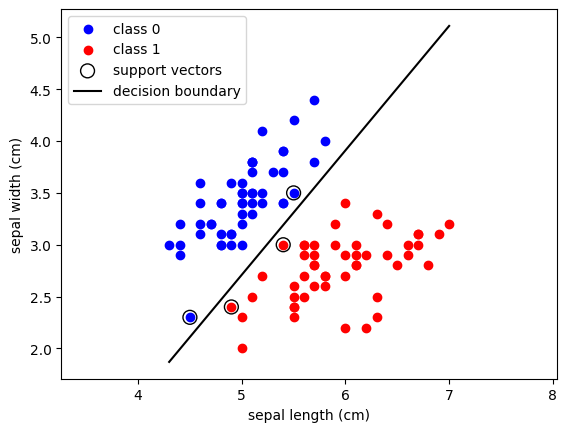

In [7]:
import numpy as np
import matplotlib.pyplot as plt

supvectors = SVMmodel.support_vectors_

# coefficients de la droite de séparation : w0*x0 + w1*x1 + b = 0
W = SVMmodel.coef_
b = SVMmodel.intercept_

print("W =", W)
print("b =", b)

# nuage de points
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='class 1')

# support vectors
plt.scatter(supvectors[:, 0], supvectors[:, 1], facecolors='none', edgecolors='black', s=100, label='support vectors')

# droite de décision
x1 = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 200)
x2 = -(W[0,0]*x1 + b[0]) / W[0,1]

plt.plot(x1, x2, color='black', label='decision boundary')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.axis('equal')
plt.show()


# Anomaly detection via SVM

Import one-class SVM and generate data (Gaussian blobs in 2D-plane):

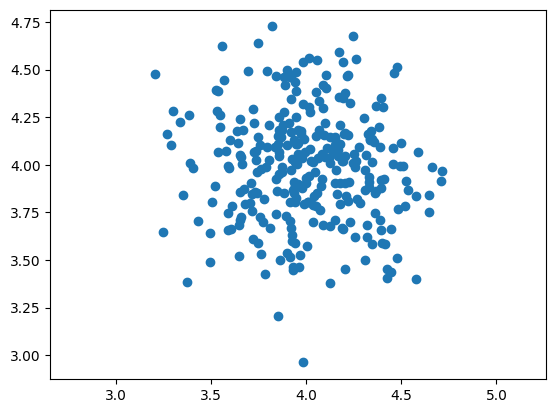

In [8]:
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from numpy import quantile, where, random

random.seed(11)
x, _ = make_blobs(n_samples=300, centers=1, cluster_std=.3, center_box=(4, 4))

plt.scatter(x[:,0], x[:,1])
plt.axis('equal')
plt.show()



Train one-class SVM and plot the outliers (outputs of prediction being equal to -1)

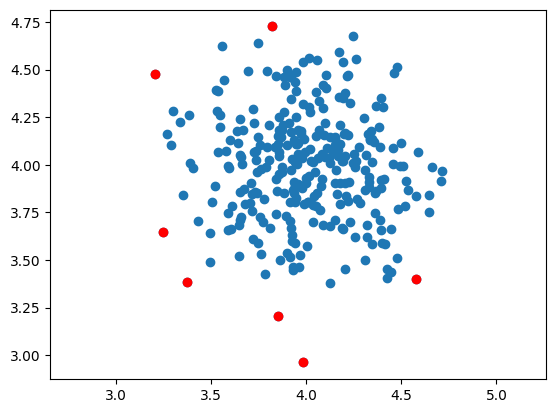

In [9]:
SVMmodelOne = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)


SVMmodelOne.fit(x)
pred = SVMmodelOne.predict(x)
anom_index = where(pred==-1)
values = x[anom_index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()



Plot the support vectors:

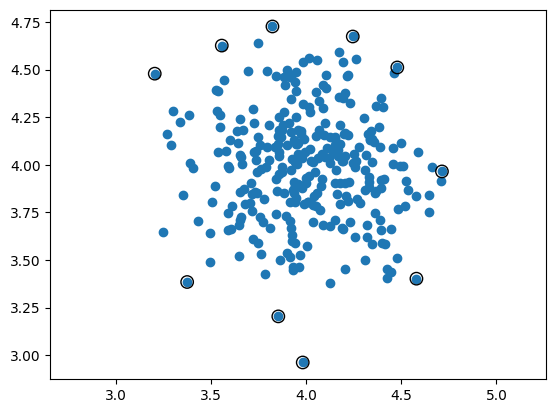

In [10]:
supvectors_one = SVMmodelOne.support_vectors_

plt.scatter(x[:,0], x[:,1])
plt.scatter(supvectors_one[:,0], supvectors_one[:,1], facecolors='none', edgecolors='black', s=80)
plt.axis('equal')
plt.show()


What if we want to have a control what is outlier? Use e.g. 5% "quantile" to mark the outliers. Every point with lower score than threshold will be an outlier.

threshold = 8.989098620408397


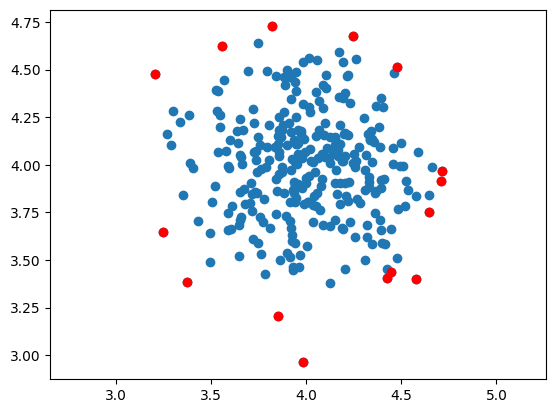

In [11]:
scores = SVMmodelOne.score_samples(x)

thresh = quantile(scores, 0.05)  # 5% d'outliers
print("threshold =", thresh)

index = where(scores <= thresh)
values = x[index]

plt.scatter(x[:,0], x[:,1])
plt.scatter(values[:,0], values[:,1], color='red')
plt.axis('equal')
plt.show()
